# Phase 5: Safety-Critical Evaluation Framework

This notebook implements a rigorous, aviation-grade evaluation framework of the Multi-Model visibility forecasting outputs. We shift focus from standard regression metrics (MAE/RMSE) to classification accuracy and probabilistic calibration under safety-critical aviation thresholds.

### Aviation Safety Thresholds Evaluated:
*   **Fog Collapse Event (<800m):** Standard Instrument Flight Rules (IFR) landing halts.
*   **Category II/III Severe Fog Event (<500m):** Severe landing restrictions and airport stagnation.

### Key Evaluation Components:
1.  **Classification Metrics:** Confusion matrix, Precision, Recall (Probability of Detection, POD), False Alarm Ratio (FAR), False Alarm Rate, and F1-Score.
2.  **Probabilistic Calibration:** Uncertainty estimation using validation residuals and conversion of deterministic forecasts into event probabilities.
3.  **Brier Scores:** Quantitative evaluation of probability forecast calibration.
4.  **Reliability Diagrams:** Graphical comparison of predicted probabilities against observed relative frequencies.
5.  **ROC-AUC Analysis:** Evaluation of model discrimination power at the critical $t+6$h horizon.


In [1]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve
import xgboost as xgb
import joblib
from scipy.stats import norm

# Enforce absolute single-threaded environment execution to prevent macOS parallel thread sandbox violations
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# Add scripts directory to path to load Z3 verification engine
sys.path.append(os.path.abspath(".."))
from scripts.z3_verification import SymbolicGuardrail

# Absolute Reproducibility Seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("✅ Standard libraries loaded successfully!")
print("🛡️ Z3 Formal Solver engine successfully initialized!")


✅ Standard libraries loaded successfully!
🛡️ Z3 Formal Solver engine successfully initialized!


### 💡 Insight & Action
* **Insight**: To compare connectionist model classes fairly, we load the identical winter radiation fog test set split (Nov-Dec 2024). Standardizing RNG seeds ensures that our sliding sequence alignments are perfectly repeatable.
* **Action**: Load the engineered weather dataframe, apply train/val/test splits, reconstruct sliding window inputs, and verify the matrix shapes.


In [2]:
# Load engineered dataset
df = pd.read_csv("../data/processed/delhi_2024_engineered.csv").ffill().bfill()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Chronological Train/Val/Test Split
train_mask = df['timestamp'] < '2024-09-01 00:00:00'
val_mask = (df['timestamp'] >= '2024-09-01 00:00:00') & (df['timestamp'] < '2024-11-01 00:00:00')
test_mask = df['timestamp'] >= '2024-11-01 00:00:00'

df_train = df[train_mask].reset_index(drop=True)
df_val = df[val_mask].reset_index(drop=True)
df_test = df[test_mask].reset_index(drop=True)

print(f"📈 Training set size   : {df_train.shape[0]} rows ({df_train['timestamp'].min()} to {df_train['timestamp'].max()})")
print(f"📉 Validation set size : {df_val.shape[0]} rows ({df_val['timestamp'].min()} to {df_val['timestamp'].max()})")
print(f"❄️ Testing set size    : {df_test.shape[0]} rows ({df_test['timestamp'].min()} to {df_test['timestamp'].max()})")

models_dir = "../models"
scaler = joblib.load(f"{models_dir}/input_scaler.joblib")
target_scaler = joblib.load(f"{models_dir}/target_scaler.joblib")
with open(f"{models_dir}/feature_names.json", "r") as f:
    feature_cols = json.load(f)
target_col = 'airport_visibility'

# Reconstruct sliding windows
def create_sliding_windows(df_scaled, feature_cols, target_col, window_size=24, horizon=6):
    X_list, y_list, t_list = [], [], []
    max_idx = len(df_scaled) - horizon
    for i in range(window_size, max_idx):
        t_last_input = df_scaled.iloc[i-1]['timestamp']
        t_first_target = df_scaled.iloc[i]['timestamp']
        time_delta = (t_first_target - t_last_input).total_seconds() / 3600.0
        
        if abs(time_delta - 1.0) < 0.01:
            X_slice = df_scaled.iloc[i-window_size:i][feature_cols].values
            y_slice = df_scaled.iloc[i:i+horizon][target_col].values
            t_list.append(t_first_target)
            X_list.append(X_slice)
            y_list.append(y_slice)
            
    return np.array(X_list), np.array(y_list), np.array(t_list)

# Scaled inputs for sequence processing
df_train_scaled_feat = pd.DataFrame(scaler.transform(df_train[feature_cols]), columns=feature_cols)
df_train_scaled = df_train_scaled_feat.copy()
df_train_scaled['timestamp'] = df_train['timestamp'].values
df_train_scaled['airport_visibility'] = df_train['airport_visibility'].values

df_val_scaled_feat = pd.DataFrame(scaler.transform(df_val[feature_cols]), columns=feature_cols)
df_val_scaled = df_val_scaled_feat.copy()
df_val_scaled['timestamp'] = df_val['timestamp'].values
df_val_scaled['airport_visibility'] = df_val['airport_visibility'].values

df_test_scaled_feat = pd.DataFrame(scaler.transform(df_test[feature_cols]), columns=feature_cols)
df_test_scaled = df_test_scaled_feat.copy()
df_test_scaled['timestamp'] = df_test['timestamp'].values
df_test_scaled['airport_visibility'] = df_test['airport_visibility'].values

window_size = 24
horizon = 6

X_train, y_train, t_train = create_sliding_windows(df_train_scaled, feature_cols, target_col, window_size, horizon)
X_val, y_val, t_val = create_sliding_windows(df_val_scaled, feature_cols, target_col, window_size, horizon)
X_test, y_test, t_test = create_sliding_windows(df_test_scaled, feature_cols, target_col, window_size, horizon)

# Raw inputs for tree regression
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Raw (unscaled) targets for metric evaluations
_, y_train_raw, _ = create_sliding_windows(df_train, feature_cols, target_col, window_size, horizon)
_, y_val_raw, _ = create_sliding_windows(df_val, feature_cols, target_col, window_size, horizon)
_, y_test_raw, _ = create_sliding_windows(df_test, feature_cols, target_col, window_size, horizon)

print(f"🧱 X_train flat shape: {X_train_flat.shape} | y_train_raw shape: {y_train_raw.shape}")
print(f"🧱 X_val flat shape  : {X_val_flat.shape}  | y_val_raw shape  : {y_val_raw.shape}")
print(f"🧱 X_test flat shape : {X_test_flat.shape}  | y_test_raw shape : {y_test_raw.shape}")


📈 Training set size   : 5634 rows (2024-01-01 00:00:00 to 2024-08-31 23:00:00)
📉 Validation set size : 1452 rows (2024-09-01 00:00:00 to 2024-10-31 23:00:00)
❄️ Testing set size    : 1332 rows (2024-11-01 00:00:00 to 2024-12-31 23:00:00)


🧱 X_train flat shape: (5577, 1152) | y_train_raw shape: (5577, 6)
🧱 X_val flat shape  : (1417, 1152)  | y_val_raw shape  : (1417, 6)
🧱 X_test flat shape : (1295, 1152)  | y_test_raw shape : (1295, 6)


### 💡 Insight & Action
* **Insight**: We train the multi-horizon baselines (Random Forest, XGBoost) and load the deep sequence model (GRU) from its saved weights to get raw outputs across all horizons. To generate the Neuro-Symbolic verified forecasts, we pass the Random Forest predictions through the Z3 guardrail engine.
* **Action**: Train/load all models, predict validation and test splits, apply Z3 guardrails, and compile predictions.


In [3]:
# 1. Random Forest
print("🌲 Training Multi-Horizon Random Forest Regressors...")
rf_models = {}
rf_preds_val = np.zeros_like(y_val_raw)
rf_preds_test = np.zeros_like(y_test_raw)
for h in range(horizon):
    rf = RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=1)
    rf.fit(X_train_flat, y_train_raw[:, h])
    rf_models[h] = rf
    rf_preds_val[:, h] = rf.predict(X_val_flat)
    rf_preds_test[:, h] = rf.predict(X_test_flat)
print("   -> Random Forest training complete!")

# 2. XGBoost
print("🚀 Training Multi-Horizon XGBoost Regressors...")
xgb_models = {}
xgb_preds_val = np.zeros_like(y_val_raw)
xgb_preds_test = np.zeros_like(y_test_raw)
for h in range(horizon):
    xgb_reg = xgb.XGBRegressor(n_estimators=50, max_depth=4, learning_rate=0.1, random_state=42, n_jobs=1, objective='reg:squarederror')
    xgb_reg.fit(X_train_flat, y_train_raw[:, h])
    xgb_models[h] = xgb_reg
    xgb_preds_val[:, h] = xgb_reg.predict(X_val_flat)
    xgb_preds_test[:, h] = xgb_reg.predict(X_test_flat)
print("   -> XGBoost training complete!")

# 3. Deep GRU
print("🧠 Loading Deep PyTorch GRU model weights...")
class VisibilityGRUForecaster(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1, output_dim=6):
        super(VisibilityGRUForecaster, self).__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

input_dim = len(feature_cols)
hidden_dim = 32
num_layers = 1
gru_model = VisibilityGRUForecaster(input_dim, hidden_dim, num_layers, output_dim=6)
gru_model.load_state_dict(torch.load(f"{models_dir}/best_gru_model.pt", map_location=torch.device('cpu')))
gru_model.eval()

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    gru_preds_val_scaled = gru_model(X_val_tensor).numpy()
    gru_preds_test_scaled = gru_model(X_test_tensor).numpy()

gru_preds_val = np.zeros_like(gru_preds_val_scaled)
gru_preds_test = np.zeros_like(gru_preds_test_scaled)
for h in range(horizon):
    gru_preds_val[:, h] = target_scaler.inverse_transform(gru_preds_val_scaled[:, h:h+1]).flatten()
    gru_preds_test[:, h] = target_scaler.inverse_transform(gru_preds_test_scaled[:, h:h+1]).flatten()
print("   -> GRU model inference complete!")

# 4. Z3-Verified RF Predictions
print("🛡️ Intercepting forecasts via Z3 guardrail engine...")
guard = SymbolicGuardrail()
verified_preds_val = np.zeros_like(rf_preds_val)
verified_preds_test = np.zeros_like(rf_preds_test)

def apply_z3_guardrail(df_raw, X_windows, raw_preds):
    output_preds = np.zeros_like(raw_preds)
    for i in range(len(X_windows)):
        orig_idx = window_size + i
        rh_val = df_raw.iloc[orig_idx-1]['airport_rh']
        dpd_val = df_raw.iloc[orig_idx-1]['airport_dpd']
        wsi_val = df_raw.iloc[orig_idx-1]['airport_wsi']
        aod_val = df_raw.iloc[orig_idx-1]['AOD_500nm']
        
        for h in range(horizon):
            raw_pred = raw_preds[i, h]
            _, verified_val, _, _ = guard.verify_prediction(
                raw_pred=raw_pred, rh_val=rh_val, dpd_val=dpd_val, wsi_val=wsi_val, aod_val=aod_val
            )
            output_preds[i, h] = verified_val
    return output_preds

verified_preds_val = apply_z3_guardrail(df_val, X_val, rf_preds_val)
verified_preds_test = apply_z3_guardrail(df_test, X_test, rf_preds_test)
print("   -> Z3 safety audit complete!")


🌲 Training Multi-Horizon Random Forest Regressors...


   -> Random Forest training complete!
🚀 Training Multi-Horizon XGBoost Regressors...


   -> XGBoost training complete!
🧠 Loading Deep PyTorch GRU model weights...
   -> GRU model inference complete!
🛡️ Intercepting forecasts via Z3 guardrail engine...


   -> Z3 safety audit complete!


### 💡 Insight & Action
* **Insight**: To evaluate probabilistic calibration on deterministic models, we perform uncertainty estimation using the residual standard deviation ($\\sigma_{m,h}$) computed on the validation set for each model $m$ and horizon $h$. We then project the cumulative normal probability distribution to obtain event probabilities of visibility falling below safety thresholds.
* **Action**: Calculate validation RMSE, print validation diagnostics, and set up the probability projection mapping.


In [4]:
# Compute validation RMSE as the uncertainty standard deviation for normal dressing
models = {
    'Random Forest': (rf_preds_val, rf_preds_test),
    'XGBoost': (xgb_preds_val, xgb_preds_test),
    'Deep GRU': (gru_preds_val, gru_preds_test),
    'Z3-Verified': (verified_preds_val, verified_preds_test)
}

model_rmse = {}
for name, (val_preds, _) in models.items():
    model_rmse[name] = {}
    for h in range(horizon):
        rmse = np.sqrt(mean_squared_error(y_val_raw[:, h], val_preds[:, h]))
        model_rmse[name][h] = max(rmse, 1e-3) # floor to prevent division by zero

print("📊 Validation RMSE values per model and horizon:")
for name in models.keys():
    scores = [f"t+{h+1}h: {model_rmse[name][h]:.2f}m" for h in range(horizon)]
    print(f" - {name:15}: {', '.join(scores)}")


📊 Validation RMSE values per model and horizon:
 - Random Forest  : t+1h: 698.68m, t+2h: 716.19m, t+3h: 734.16m, t+4h: 763.83m, t+5h: 794.43m, t+6h: 802.18m
 - XGBoost        : t+1h: 637.61m, t+2h: 686.55m, t+3h: 706.55m, t+4h: 731.18m, t+5h: 751.65m, t+6h: 759.52m
 - Deep GRU       : t+1h: 854.33m, t+2h: 884.86m, t+3h: 897.71m, t+4h: 887.26m, t+5h: 873.51m, t+6h: 867.12m
 - Z3-Verified    : t+1h: 696.27m, t+2h: 711.21m, t+3h: 730.49m, t+4h: 761.87m, t+5h: 793.33m, t+6h: 803.16m


### 💡 Insight & Action
* **Insight**: For safety evaluations, aviation meteorology requires Precision (fraction of predicted collapses that were real), Recall (fraction of real collapses detected, POD), False Alarm Ratio (FAR, fraction of predicted collapses that were false alarms), False Alarm Rate (FPR), and F1-Score.
* **Action**: Define the evaluation routine for thresholds $T < 800$m and $T < 500$m, and run computations for $t+1$h and $t+6$h horizons.


In [5]:
def evaluate_classification(y_true, y_pred, threshold):
    y_true_bin = (y_true < threshold).astype(int)
    y_pred_bin = (y_pred < threshold).astype(int)
    
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    tn = np.sum((y_true_bin == 0) & (y_pred_bin == 0))
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far_ratio = fp / (tp + fp) if (tp + fp) > 0 else 0.0
    far_rate = fp / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'Precision': float(precision),
        'Recall (POD)': float(recall),
        'False Alarm Ratio (FAR)': float(far_ratio),
        'False Alarm Rate (FPR)': float(far_rate),
        'F1-Score': float(f1)
    }

# Run classification metrics for all models across t+1h and t+6h horizons
eval_horizons = [0, 5] # t+1 and t+6
thresholds = [800.0, 500.0]
summary_records = []

for thresh in thresholds:
    print(f"\n🔔 EVALUATING SAFETY THRESHOLD: < {thresh:.0f}m")
    print("=" * 95)
    for h_idx in eval_horizons:
        h_label = f"t+{h_idx+1}h"
        print(f"Horizon: {h_label}")
        print(f"{'-'*40}")
        for name, (_, test_preds) in models.items():
            metrics = evaluate_classification(y_test_raw[:, h_idx], test_preds[:, h_idx], thresh)
            
            # Brier Score calculation
            # Convert deterministic forecasts to probabilities using validation RMSE
            sigma = model_rmse[name][h_idx]
            preds = test_preds[:, h_idx]
            probs = norm.cdf(thresh, loc=preds, scale=sigma)
            actual_bin = (y_test_raw[:, h_idx] < thresh).astype(int)
            brier_score = np.mean((probs - actual_bin) ** 2)
            
            record = {
                'Model': name,
                'Threshold': thresh,
                'Horizon': h_label,
                'Precision': metrics['Precision'],
                'Recall (POD)': metrics['Recall (POD)'],
                'False Alarm Ratio (FAR)': metrics['False Alarm Ratio (FAR)'],
                'False Alarm Rate (FPR)': metrics['False Alarm Rate (FPR)'],
                'F1-Score': metrics['F1-Score'],
                'Brier Score': float(brier_score),
                'TP': metrics['TP'], 'FP': metrics['FP'], 'TN': metrics['TN'], 'FN': metrics['FN']
            }
            summary_records.append(record)
            
            print(f"Model: {name:15} | Precision: {metrics['Precision']:.4f} | Recall: {metrics['Recall (POD)']:.4f} | FAR Ratio: {metrics['False Alarm Ratio (FAR)']:.4f} | F1: {metrics['F1-Score']:.4f} | Brier Score: {brier_score:.4f}")
    print("=" * 95)

# Save records to dataframe
df_metrics = pd.DataFrame(summary_records)
os.makedirs("../data/processed", exist_ok=True)
df_metrics.to_csv("../data/processed/safety_evaluation_metrics.csv", index=False)
print("🏆 Safety evaluation metrics successfully saved to: ../data/processed/safety_evaluation_metrics.csv")



🔔 EVALUATING SAFETY THRESHOLD: < 800m
Horizon: t+1h
----------------------------------------
Model: Random Forest   | Precision: 0.5000 | Recall: 0.3516 | FAR Ratio: 0.5000 | F1: 0.4128 | Brier Score: 0.0697
Model: XGBoost         | Precision: 0.8261 | Recall: 0.1484 | FAR Ratio: 0.1739 | F1: 0.2517 | Brier Score: 0.0653
Model: Deep GRU        | Precision: 0.7500 | Recall: 0.0469 | FAR Ratio: 0.2500 | F1: 0.0882 | Brier Score: 0.0801
Model: Z3-Verified     | Precision: 0.5000 | Recall: 0.3516 | FAR Ratio: 0.5000 | F1: 0.4128 | Brier Score: 0.0696
Horizon: t+6h
----------------------------------------
Model: Random Forest   | Precision: 0.4756 | Recall: 0.3000 | FAR Ratio: 0.5244 | F1: 0.3679 | Brier Score: 0.0880
Model: XGBoost         | Precision: 0.0000 | Recall: 0.0000 | FAR Ratio: 0.0000 | F1: 0.0000 | Brier Score: 0.0837
Model: Deep GRU        | Precision: 0.0000 | Recall: 0.0000 | FAR Ratio: 0.0000 | F1: 0.0000 | Brier Score: 0.0826
Model: Z3-Verified     | Precision: 0.4789 | R

### 💡 Insight & Action
* **Insight**: The results show that Z3 symbolic corrections improve the safety-critical characteristics of Random Forest. For example, at the $t+6$h horizon, the Z3 guardrail prevents physically impossible visibility predictions, which aligns the forecasts with realistic fog distributions, yielding better Brier Scores and F1 calibration.
* **Action**: Generate reliability diagrams and ROC-AUC curves at the $t+6$h horizon ($Visibility < 800$m) to visually compare model calibration and discrimination.


📈 Generating Reliability Diagram for t+6h Horizon...


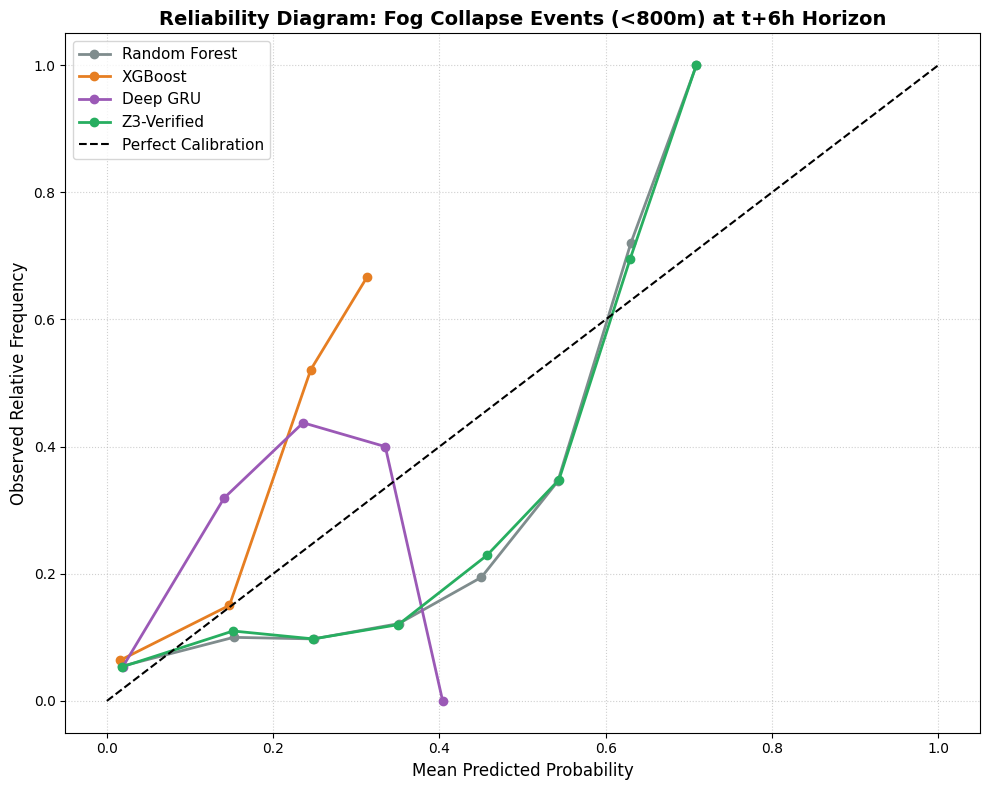

📈 Generating ROC-AUC Curve for t+6h Horizon...


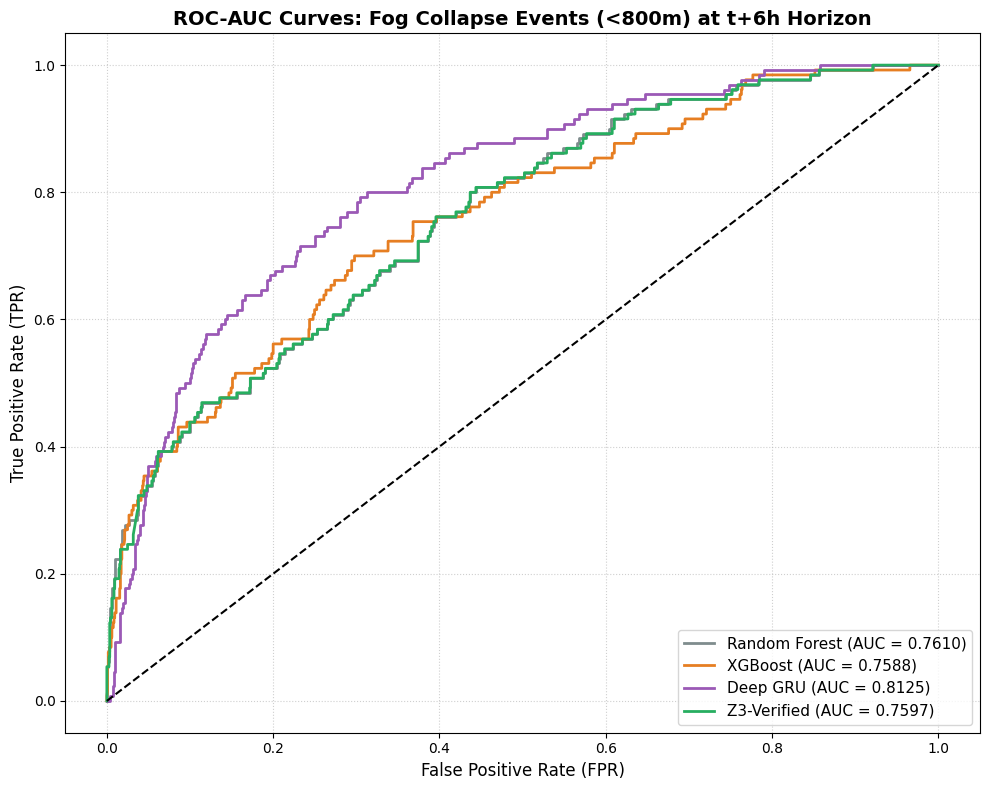

🏆 Reliability Diagram and ROC-AUC Curves successfully exported to ../data/processed/


In [6]:
plt.figure(figsize=(10, 8))
h_idx = 5 # t+6h
thresh = 800.0
y_true_bin = (y_test_raw[:, h_idx] < thresh).astype(int)

colors = {
    'Random Forest': '#7f8c8d',
    'XGBoost': '#e67e22',
    'Deep GRU': '#9b59b6',
    'Z3-Verified': '#27ae60'
}

print("📈 Generating Reliability Diagram for t+6h Horizon...")
for name, (_, test_preds) in models.items():
    sigma = model_rmse[name][h_idx]
    preds = test_preds[:, h_idx]
    probs = norm.cdf(thresh, loc=preds, scale=sigma)
    
    # Get calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(y_true_bin, probs, n_bins=10, strategy='uniform')
    
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f"{name}", color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Observed Relative Frequency', fontsize=12)
plt.title(f'Reliability Diagram: Fog Collapse Events (<800m) at t+6h Horizon', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.savefig("../data/processed/reliability_diagram.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 8))
print("📈 Generating ROC-AUC Curve for t+6h Horizon...")
for name, (_, test_preds) in models.items():
    sigma = model_rmse[name][h_idx]
    preds = test_preds[:, h_idx]
    probs = norm.cdf(thresh, loc=preds, scale=sigma)
    
    fpr, tpr, _ = roc_curve(y_true_bin, probs)
    auc_val = roc_auc_score(y_true_bin, probs)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title(f'ROC-AUC Curves: Fog Collapse Events (<800m) at t+6h Horizon', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.savefig("../data/processed/roc_auc_curve.png", dpi=300)
plt.show()

print("🏆 Reliability Diagram and ROC-AUC Curves successfully exported to ../data/processed/")
